In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split 

# Data Preprocessing

Splitting data into a 70/30 train test split

In [166]:
df = pd.read_csv("train.csv")
df = df.assign(logPrice = np.log(1 + df["price"]) )

discard = ["is_business_travel_ready",
           "require_guest_profile_picture",
           "city", "state", "market",'host_is_superhost',
           'host_has_profile_pic', 'require_guest_profile_picture',
           'country', 'require_guest_phone_verification','bed_type',
           'host_neighbourhood'

           
           
           ]




df = df.drop(discard, axis = 1)
df, dfTest = train_test_split(df, train_size = 0.7, test_size = 0.3, random_state = 42)

/var/folders/n_/c6t56ghn0x7bq_btsym_63b00000gn/T/ipykernel_69320/407822535.py:1: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("train.csv")


In [ ]:
for col in df.select_dtypes(include = ['float64','int64']).columns:
    p = df["logPrice"].corr(df[col])
    print(f"Correlation for col {col}: {p}")

# accomedates
# kid friendly 
# tv

Correlation for col id: -0.051177971322874355
Correlation for col host_id: -0.03759571822510476
Correlation for col host_acceptance_rate: nan
Correlation for col host_listings_count: 0.0900317435418606
Correlation for col accommodates: 0.5433682158773547
Correlation for col bathrooms: 0.18170739437650607
Correlation for col bedrooms: 0.3340083413775221
Correlation for col beds: 0.4100439630032476
Correlation for col square_feet: 0.3334478289449747
Correlation for col price: 0.8518329734768572
Correlation for col guests_included: 0.3225592941972921
Correlation for col minimum_nights: 0.029509754533087972
Correlation for col maximum_nights: 0.0013492308954266812
Correlation for col number_of_reviews: -0.01337617456405904
Correlation for col review_scores_rating: 0.07913481133463333
Correlation for col review_scores_accuracy: 0.03255839775496569
Correlation for col review_scores_cleanliness: 0.08318274205584267
Correlation for col review_scores_checkin: 0.019674403451203068
Correlation fo

np.float64(0.508762794252977)

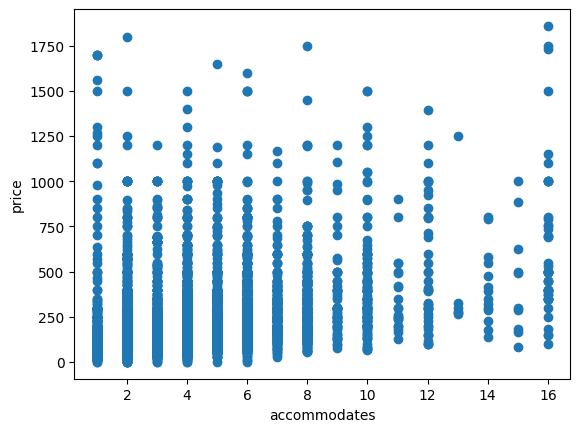

In [168]:
x = "accommodates"
y = "price"
plt.scatter(df[x], df[y])
plt.xlabel(x)
plt.ylabel(y)
df[x].corr(df[y])

In [261]:
test = df.assign(wifi = df["amenities"].str.lower().str.contains("tv"))

In [262]:
test.groupby("wifi")["price"].agg({"median", "count"})

,count,median
wifi,,
False,7498,80.0
True,15978,127.0


In [254]:
df["amenities"].iloc[50]

'{TV,"Cable TV",Wifi,"Air conditioning",Kitchen,Heating,"Family/kid friendly","Smoke detector","Carbon monoxide detector",Hangers,"Hair dryer",Iron,"Self check-in",Keypad,Microwave,Refrigerator,"Dishes and silverware","Cooking basics",Stove,"Long term stays allowed","Wide hallway clearance"}'